### Trading Causes Exponential Distribution of Wealth.

from:
<br> - https://www.youtube.com/watch?v=NusYLzb-Uho&t=350s
<br> - http://physics.umd.edu/~yakovenk/econophysics/animation.html
<br>
<br>At the beginning everyone has $50,000, and graph is a delta function.
<br>When trading starts, the graph spreads into normal distribution.
<br>Then it spreads more, eventually into exponential distribution.
<br>
<br>Two tips about of this notebook:
<br> - same graph is being refreshed using ```clear_output(wait=True)```
<br> - if you stop the execution by interrupting the kernel, it stops gracefully without the red error trace

In [18]:
import os, sys, time, random
from IPython.display import clear_output
from matplotlib import pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [38]:
def mygraph(vals, trades=0, stat_str = "", range=(-50000, 10**6)):
    clear_output(wait=True)
    plt.figure(figsize=(8,3))
    plt.hist(vals, bins=125, range=range)
    trades_str = "{:,}".format(trades)
    mytitle = "Distribution of Wealth after %s trades. " % trades_str
    if len(stat_str) <=0 :
        stat_str = "\nPress stop button (square) to stop execution."
    plt.title(mytitle + stat_str)
    plt.grid(True)
    plt.show();

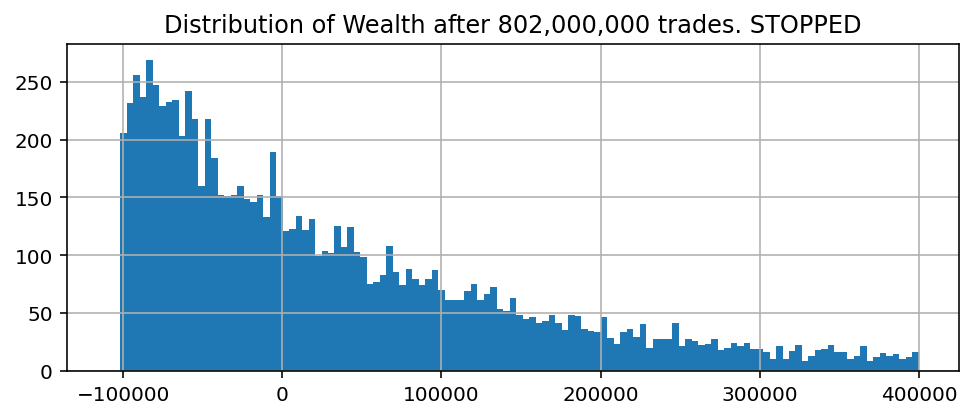

In [39]:
data = {}
N = 10000   # number of people
N1= N-1

orig_wealth = 50000                 # in dollars
trade_amount = 0.02 * orig_wealth   # in dollars
debt_allowed = -2*orig_wealth       # max debt - cr. cards + loans
graph_range = (1.1*debt_allowed, 8*orig_wealth)

vals = [orig_wealth]*N
N_trades = 10**6
try:
    for i in range(10**9):                 # time
        mygraph(vals, trades=i*N_trades, range=graph_range) # redraw histogram
        i += 1
        for j in range(N_trades):          # several trades before re-drawing the graph
            i1 = random.randint(0,N1)      # select one person
            i2 = random.randint(0,N1)      # select another person
            while (i2 == i1):
                i1 = random.randint(0,N1)
                i2 = random.randint(0,N1)
            # ---------
            loss_n = random.randint(0,1)   # 0 or 1 - coin toss
            # remove cases when a person can not trade down
            if (loss_n==0) and (vals[i1] <= debt_allowed):
                continue
            if (loss_n==1) and (vals[i2] <= debt_allowed):
                continue
            # trade:
            if loss_n == 0:   # i1 has lost
                vals[i1] -= trade_amount # loss
                vals[i2] += trade_amount # gain
            else:
                vals[i1] += trade_amount # gain
                vals[i2] -= trade_amount # loss

except KeyboardInterrupt:
    mygraph(vals, trades=(i+1)*N_trades, stat_str="STOPPED", range=graph_range)